In [1]:
import torch
import torch.nn as nn

# Test
# Input (X) and Target (y)
# We want the model to learn that y = x^2
X = torch.tensor([[1.0], [2.0], [3.0], [4.0], [5.0], [6.0], [7.0]], dtype=torch.float32)
y = torch.tensor([[1.0], [4.0], [9.0], [16.0], [25.0], [36.0], [49.0]], dtype=torch.float32)

# A simple model with 1 input and 1 output
model = nn.Sequential(
    nn.Linear(1, 10),
    nn.LeakyReLU(),
    nn.Linear(10, 10),
    nn.LeakyReLU(),
    nn.Linear(10, 1)
)

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.0001)

In [2]:
for epoch in range(10_000):
    # 1. Forward pass: Compute predicted y by passing X to the model
    y_pred = model(X)

    # 2. Compute loss
    loss = criterion(y_pred, y)

    # 3. Zero gradients, perform a backward pass, and update weights
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 20 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

Epoch 20, Loss: 521.0367
Epoch 40, Loss: 195.6326
Epoch 60, Loss: 50.1566
Epoch 80, Loss: 45.7114
Epoch 100, Loss: 45.0819
Epoch 120, Loss: 44.4817
Epoch 140, Loss: 43.8893
Epoch 160, Loss: 43.3042
Epoch 180, Loss: 42.7168
Epoch 200, Loss: 42.1149
Epoch 220, Loss: 41.5182
Epoch 240, Loss: 40.9261
Epoch 260, Loss: 40.3380
Epoch 280, Loss: 39.7288
Epoch 300, Loss: 39.0833
Epoch 320, Loss: 38.4079
Epoch 340, Loss: 37.7208
Epoch 360, Loss: 37.1244
Epoch 380, Loss: 36.5765
Epoch 400, Loss: 36.0324
Epoch 420, Loss: 35.4919
Epoch 440, Loss: 34.9551
Epoch 460, Loss: 34.4217
Epoch 480, Loss: 33.8916
Epoch 500, Loss: 33.3649
Epoch 520, Loss: 32.8414
Epoch 540, Loss: 32.3211
Epoch 560, Loss: 31.8041
Epoch 580, Loss: 31.2902
Epoch 600, Loss: 30.7795
Epoch 620, Loss: 30.2721
Epoch 640, Loss: 29.7680
Epoch 660, Loss: 29.2674
Epoch 680, Loss: 28.7702
Epoch 700, Loss: 28.2765
Epoch 720, Loss: 27.7867
Epoch 740, Loss: 27.3007
Epoch 760, Loss: 26.8187
Epoch 780, Loss: 26.3410
Epoch 800, Loss: 25.8677
Ep

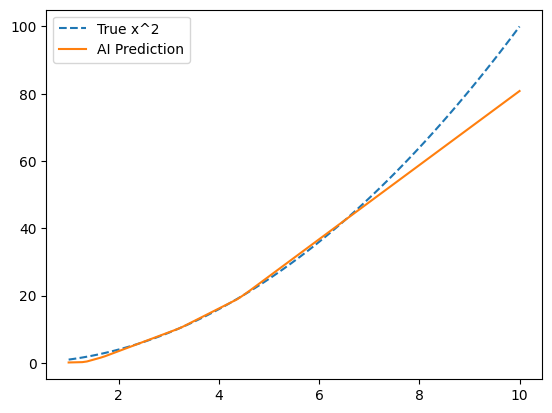

In [3]:
import matplotlib.pyplot as plt

# Generate range of x from 1 to 10
x_test = torch.linspace(1, 10, 100).reshape(-1, 1)
with torch.no_grad():
    y_pred = model(x_test)

plt.plot(x_test, x_test**2, label='True x^2', linestyle='--')
plt.plot(x_test, y_pred, label='AI Prediction')
plt.legend()
plt.show()